In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

from pythainlp.tokenize import word_tokenize
from pythainlp.corpus import thai_stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("Dataset-NlpProject - Sheet1.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (10, 2)
   Label                               Text
0      0     รัฐบาลประกาศนโยบายเศรษฐกิจใหม่
1      1          ทีมชาติไทยคว้าแชมป์ฟุตบอล
2      2     บริษัทเปิดตัวสมาร์ทโฟนรุ่นใหม่
3      3   ภาพยนตร์ไทยทำรายได้สูงสุดในปีนี้
4      4  ตลาดหุ้นไทยปรับตัวเพิ่มขึ้นวันนี้


In [3]:
def clean_text(text):
    text = re.sub(r"[^\u0E00-\u0E7Fa-zA-Z\s]", "", str(text))
    return text

def remove_stopwords(text):
    stopwords = set(thai_stopwords())
    tokens = word_tokenize(text)
    return " ".join([w for w in tokens if w not in stopwords])

df['Text'] = df['Text'].apply(clean_text)
df['Text_clean'] = df['Text'].apply(remove_stopwords)

print("\nตัวอย่างหลังทำความสะอาด:")
print(df[['Text', 'Text_clean']].head())


ตัวอย่างหลังทำความสะอาด:
                                Text                          Text_clean
0     รัฐบาลประกาศนโยบายเศรษฐกิจใหม่       รัฐบาล ประกาศ นโยบาย เศรษฐกิจ
1          ทีมชาติไทยคว้าแชมป์ฟุตบอล       ทีม ชาติ ไทย คว้าแชมป์ ฟุตบอล
2     บริษัทเปิดตัวสมาร์ทโฟนรุ่นใหม่  บริษัท เปิดตัว สมาร์ท โฟน รุ่นใหม่
3   ภาพยนตร์ไทยทำรายได้สูงสุดในปีนี้           ภาพยนตร์ ไทย ทำ รายได้ ปี
4  ตลาดหุ้นไทยปรับตัวเพิ่มขึ้นวันนี้      ตลาดหุ้น ไทย ปรับตัว เพิ่มขึ้น


In [4]:

X = df['Text_clean']
y = df['Label']

num_classes = y.nunique()
num_samples = len(df)

print("\nNumber of samples:", num_samples)
print("Number of classes:", num_classes)

# คำนวณ test_size แบบปลอดภัย
min_test_size = num_classes / num_samples

if min_test_size < 0.2:
    test_size = 0.2
else:
    test_size = min_test_size

print("Using test_size:", round(test_size, 2))

# ถ้าข้อมูลพอ → ใช้ stratify
if num_samples >= num_classes * 2:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )
else:
    # ถ้าน้อยเกินไป → ไม่ stratify
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42
    )



Number of samples: 10
Number of classes: 5
Using test_size: 0.5


In [5]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [6]:

# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)


In [7]:

print("\n============================")
print("Naive Bayes Accuracy:",
      accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb, zero_division=0))

print("\n============================")
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, zero_division=0))


Naive Bayes Accuracy: 0.4
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.33      1.00      0.50         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         1

    accuracy                           0.40         5
   macro avg       0.17      0.40      0.23         5
weighted avg       0.17      0.40      0.23         5


Logistic Regression Accuracy: 0.4
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.33      1.00      0.50         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         1

    accuracy                           0.40         5
   macro avg       0.27      0.40      0.30         5
weighted avg   

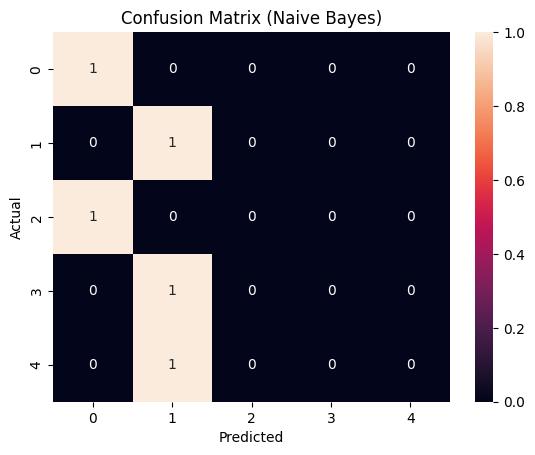

In [8]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_nb, labels=labels)

plt.figure()
sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Naive Bayes)")
plt.show()


In [9]:
def predict_text(text, model):
    text = clean_text(text)
    text = remove_stopwords(text)
    text_tfidf = vectorizer.transform([text])
    return model.predict(text_tfidf)[0]